# TD02 — Réseau mono-couche (3 perceptrons)

# Objectif
Passer d'un neurone (TD01) à une **couche de 3 perceptrons** : `h = W·x + b`, `y = argmax(h)`, apprentissage de Rosenblatt multi-classes.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

## 1. Génération de jeux de données 2D



In [52]:
def gen_jeu1(n=25, sigma=0.6, seed=0):
    rng = np.random.default_rng(seed)
    centres = [(-2,-2),(2,-2),(0,2)]
    X_list, y_list = [], []
    for k,(cx,cy) in enumerate(centres):
        pts = rng.normal(loc=(cx,cy), scale=sigma, size=(n,2))
        X_list.append(pts)
        y_list += [k]*n
    return np.vstack(X_list), np.array(y_list)

def gen_jeu2(n=15, seed=1):
    rng = np.random.default_rng(seed)
    Xa = rng.normal(loc=(0,0), scale=0.6, size=(n,2))
    Xb = rng.normal(loc=(0,0), scale=0.6, size=(n,2))
    X = np.vstack([Xa, Xb])
    y = np.array([0]*n + [1]*n)
    return X, y

## 2. Construction des jeux d'entraînement


In [53]:
X1, y1 = gen_jeu1()
_X2, _y2 = gen_jeu2()
X2 = np.vstack([X1, _X2])
y2 = np.concatenate([y1, _y2])

## 3. Outil de visualisation `display_data`
Nuage coloré par classe, aspect égal, grille. Visualisez chaque jeu avant d'entraîner.

In [54]:
def display_data(X, y, titre=None):
    couleurs = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    fig, ax = plt.subplots()
    for k in sorted(set(y)):
        ax.scatter(
            X[y == k, 0], X[y == k, 1],
            c=couleurs[k % len(couleurs)],
            edgecolors='k', s=25, label=f"classe {k}"
        )
    ax.set_aspect('equal')
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if titre:
        ax.set_title(f"{titre} ({len(X)} pts)")
    ax.legend()
    ax.grid(True)
    plt.show()

Comparer les jeux de données. Qu'est-ce que l'on peut remarquer ?

## 4. Modèle : couche mono-couche `y = argmax(Wx + b)`
`W : (K×D)`, `b : (K,)`. 

Règle de Rosenblatt multi-classes: si `pred != target`, on **renforce** le bon neurone (faux négatif) et on **punit** le mauvais gagnant (faux positif)

In [55]:
from dataclasses import dataclass
import numpy as np

@dataclass
class CoucheMonoCouche:
    W: np.ndarray
    b: np.ndarray
    # SKIP

    def predict(self, x: np.ndarray) -> int:
        h = self.W @ x + self.b
        return int(np.argmax(h))

    def learn_one(self, x: np.ndarray, t: int, r: float = 0.1):
        p = self.predict(x)
        if p != t:
            self.W[t] += r * x
            self.b[t] += r
            self.W[p] -= r * x
            self.b[p] -= r

    def train(self, X: np.ndarray, y: np.ndarray, epochs: int = 50):
        for _ in range(epochs):
            err = 0
            for xi, ti in zip(X, y):
                if self.predict(xi) != int(ti):
                    err += 1
                self.learn_one(xi, int(ti))
            if err == 0:
                break
        return self

## 5. Entraînement : jeu 1 vs jeu 2
Deux couches identiques (Exercices 2-3) : `couche1` sur `X1`, `couche2` sur `X2`. Comparez les accuracies : que se passe-t-il ?

In [56]:
def accuracy( reseau, X, y ):
    """
    Fonction qui donne un score à la précision du réseau (on réutilise les données d'entrainement)
    """
    # SKIP
    pred = np.array([reseau.predict(x) for x in X])
    return (pred==y).mean()*100

In [57]:
couche1 = CoucheMonoCouche(W=np.zeros((3,2)), b=np.zeros(3))
couche1.train(X1, y1)
acc_jeu_1 = accuracy(couche1, X1, y1)
print(f"accuracy jeu 1: {acc_jeu_1:.1f}%")
couche2 = CoucheMonoCouche(W=np.zeros((3,2)), b=np.zeros(3))
couche2.train(X2, y2)
acc_jeu_2 = accuracy(couche2, X2, y2)
print(f"accuracy jeu 2: {acc_jeu_2:.1f}%")

accuracy jeu 1: 100.0%
accuracy jeu 2: 74.3%


### 5.1 Frontieres de decision avec `plot_frontieres`
- **Fond colore** = vraie decision `argmax_k h_k` (3 regions convexes, bords = `h_i == h_j`).
- **Pointilles noirs** = zeros de chaque score `h_k = 0` (ou le neurone k bascule +/-). **Ce N'EST PAS la frontiere de decision !**
- La legende `h_k=0 (indicatif)` le rappelle.

>  Exercice 2-3 — Lire la figure
> 1. Trouvez un pointille qui traverse une zone de couleur uniforme. Que concluez-vous ?
> 2. Comparer les résultats jeu1 vs jeu2

In [23]:
def plot_frontieres(ax, X, y, couche, lim=(-4,4)):
    xx, yy = np.meshgrid(np.linspace(lim[0],lim[1],300), np.linspace(lim[0],lim[1],300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.argmax(grid @ couche.W.T + couche.b, axis=1).reshape(xx.shape)
    # fond = vraie decision argmax (bords = h_i == h_j)
    ax.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5,2.5], colors=['tab:blue','tab:orange','tab:green'], alpha=0.12)
    for k,c in enumerate(['tab:blue','tab:orange','tab:green']):
        ax.scatter(X[y==k,0], X[y==k,1], c=c, edgecolors='k', s=25, label=f"classe {k}")
    # pointilles h_k=0 : indicatif uniquement, PAS la frontiere argmax
    for k in range(3):
        H = (grid @ couche.W[k] + couche.b[k]).reshape(xx.shape)
        ax.contour(xx, yy, H, levels=[0], colors='k', linewidths=1.5, linestyles='--')
    ax.plot([], [], 'k--', label='h_k=0 (indicatif, pas frontiere)')
    ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(True)

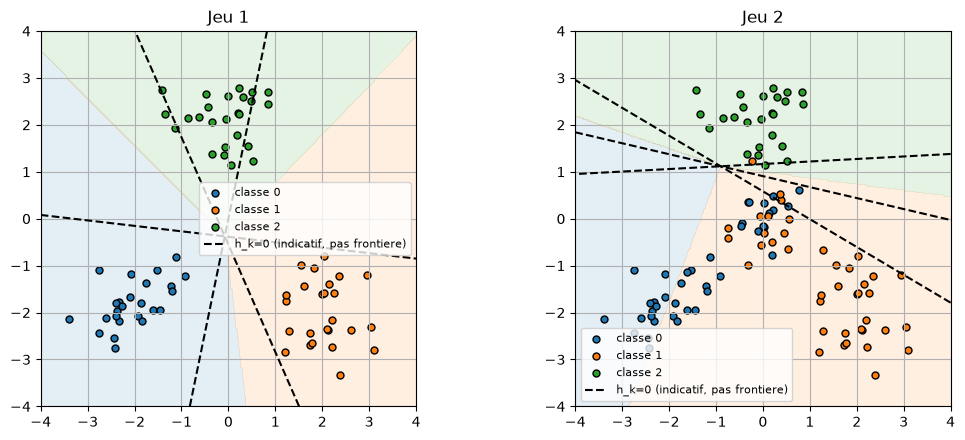

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
plot_frontieres(axes[0], X1, y1, couche1)
axes[0].set_title("Jeu 1")
plot_frontieres(axes[1], X2, y2, couche2)
axes[1].set_title("Jeu 2")
plt.tight_layout()
plt.show()

## 6. Bonus actif : lettres A/B/C en 5x5, 25D (Exercices 4-6)
Meme classe `CoucheMonoCouche` reutilisee en dimension 25 : 3 templates `TPL` encodes en `±1`, bruites par `n_flip` pixels inverses.
Objectifs : (1) montrer que le meme modele marche en 25D quand c'est separable (contraste avec le piege central), (2) lire chaque ligne de `W` comme un prototype A/B/C.

In [11]:
TPL = {
 0: np.array([0,1,0,1,0, 1,0,1,0,1, 1,1,1,1,1, 1,0,0,0,1, 1,0,0,0,1]),
 1: np.array([1,1,1,0,0, 1,0,0,1,0, 1,1,1,0,0, 1,0,0,1,0, 1,1,1,0,0]),
 2: np.array([0,1,1,1,0, 1,0,0,0,0, 1,0,0,0,0, 1,0,0,0,0, 0,1,1,1,0]),
}
def enc(v): return np.where(v==1, 1.0, -1.0)
def gen_lettres(n_per=10, n_flip=2, seed=2):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for k in range(3):
        base = enc(TPL[k])
        for _ in range(n_per):
            w = base.copy()
            idx = rng.choice(25, size=n_flip, replace=False)
            w[idx] *= -1
            X.append(w); y.append(k)
    return np.array(X), np.array(y)

### 6.1 Entrainement + comprendre les scores `h`
Train avec `n_flip=2` → ~100%. Puis on affiche **une** lettre bruitee + ses 3 scores `h = W.x + b` : le gagnant `argmax` est la prediction.

> Exercice 4 — Predire a la main
> 
> Choisissez une lettre de test, affichez-la en 5x5, lisez ses 3 scores. Quel `h_k` est le plus grand ? Retrouvez la prediction `argmax`.

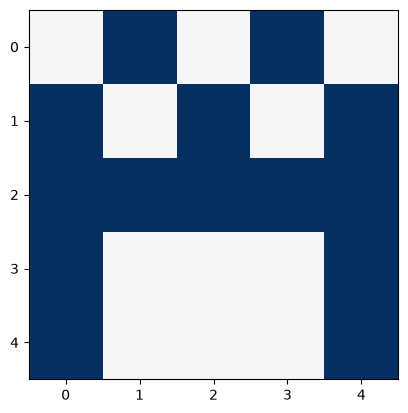

In [58]:
def affiche_lettre(lettre: np.ndarray, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(lettre.reshape(5,5), cmap="RdBu", vmin=-1, vmax=1)

affiche_lettre(TPL[0])

## Exercice

Entrainer un réseau de neurone sur des lettres générées avec 2 flip (on entraine avec un peu de bruit pour obtenir un peu de résistance au bruit).

In [42]:
X_ent, y_ent = gen_lettres() # 


# SKIP
c_let = CoucheMonoCouche(W=np.zeros((3,25)), b=np.zeros(3))
c_let.train(X_let, y_let)
pred_let = np.array([c_let.predict(x) for x in X_let])
print(f"accuracy sur le train: {(pred_let==y_let).mean()*100:.1f}%")

accuracy sur le train: 100.0%


Déterminer maintenant l'accuracy du réseau si teste le réseau sur des lettres avec 5 flip

In [44]:
# SKIP

X_let_test, y_let_test = gen_lettres(n_per=10, n_flip=5, seed=99)
pred_test = np.array([c_let.predict(x) for x in X_let_test])
print(f"accuracy lettres test flip5: {(pred_test==y_let_test).mean()*100:.1f}%")



accuracy lettres test flip5: 73.3%


## Vérification du modèle à la main

Choisir une des lettres de test, l'afficher, et vérifier que le réseau l'a bien reconnu en regardant les valeurs de sortie de chacun des neurones

In [38]:
# SKIP
h = c_let.W @ X_let_test[0] + c_let.b
h

affiche_lettre(X_let_test[0])


array([ 1. , -1.2,  0.2])

In [39]:
# Afficher la lettre X_let_test[0], ainsi que les scores associés pour chacun des neurones
# vérifier que cela correspond bien à la lettre de départ

### 6.2 Acte 1 — Lire `W` : quel prototype pour quelle lettre ?
Chaque ligne de `W` (25 nombres) re-affichee en 5x5 (`RdBu`, rouge=+1, bleu=-1) : le reseau a appris un prototype.

>  Exercice 5 — Associer
> Afficher les templates et les poids des réseaux de neurone, comme s'ils étaient des images. Que remarque-ton ?

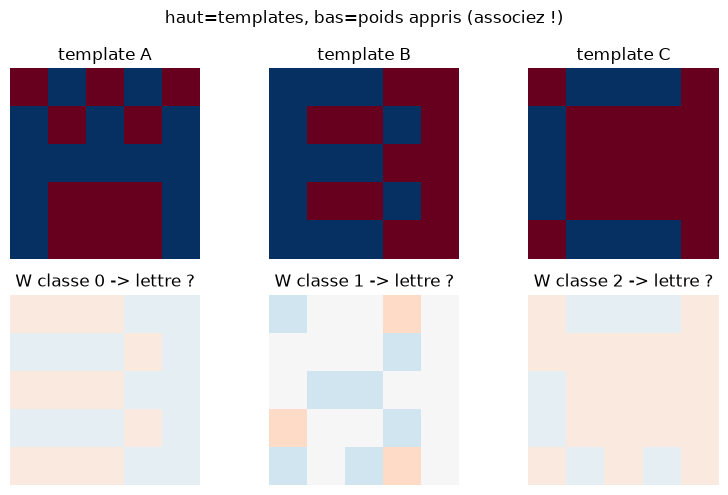

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(8,5))

# SKIP
for k in range(3):
    axes[0,k].imshow(enc(TPL[k]).reshape(5,5), cmap="RdBu", vmin=-1, vmax=1)
    axes[0,k].set_title(f"template {'ABC'[k]}")
    axes[0,k].axis("off")
    axes[1,k].imshow(c_let.W[k].reshape(5,5), cmap="RdBu", vmin=-1, vmax=1)
    axes[1,k].set_title(f"W classe {k} -> lettre ?")
    axes[1,k].axis("off")
plt.suptitle("haut=templates, bas=poids appris (associez !)")
plt.tight_layout()
plt.show()

### 6.3 Acte 2 — Courbe de robustesse au bruit (a coder)
On fait varier `n_flip` de 0 a 8 : train fixe (`n_flip=2`), test de plus en plus bruite. Tracez accuracy train vs test.
Attendu : 100% a flip 0-2, ~70% a flip 5, ~60% a flip 8. C'est une mesure de generalisation au bruit (lien partie 3 §4 surapprentissage).

> [!faq] Exercice 6 — Robustesse
> Completez la boucle `for nf in flips` + le `plt.plot`. A partir de quel `n_flip` le modele passe sous 80% ? Pourquoi ? (distance au prototype vs bruit).

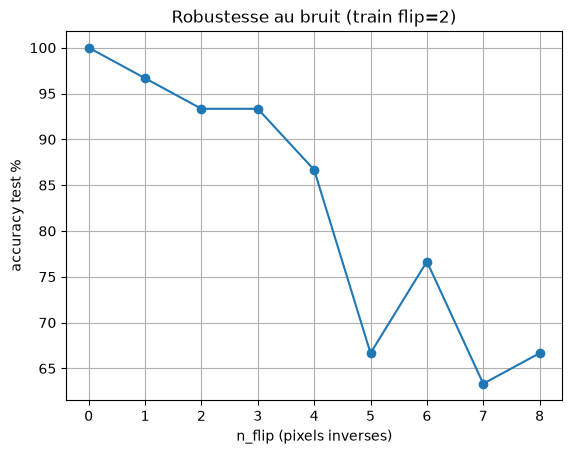

[(0, '100.0%'), (1, '96.7%'), (2, '93.3%'), (3, '93.3%'), (4, '86.7%'), (5, '66.7%'), (6, '76.7%'), (7, '63.3%'), (8, '66.7%')]


In [46]:
# SKIP
flips = list(range(0, 9))
accs = []
for nf in flips:
    Xt, yt = gen_lettres(n_per=10, n_flip=nf, seed=100+nf)
    pt = np.array([c_let.predict(x) for x in Xt])
    accs.append((pt==yt).mean()*100)
fig, ax = plt.subplots()
ax.plot(flips, accs, marker='o')
ax.set_xlabel("n_flip (pixels inverses)")
ax.set_ylabel("accuracy test %")
ax.set_title("Robustesse au bruit (train flip=2)")
ax.grid(True)
plt.show()
print(list(zip(flips, [f'{a:.1f}%' for a in accs])))

### 6.4 Acte 3 — Synthese : dimension vs separabilite

> [!danger] Exercice 7 — Synthese
> Pourquoi le meme modele echoue sur le piege central 2D mais reussit en 25D sur les lettres ?
> Reponse attendue : ce n'est pas la dimension qui compte, c'est la **separabilite lineaire**. Lettres = 3 nuages bien separes autour des prototypes (±1 + quelques flips) → Rosenblatt converge. Piege = classes 0/1 melangees au centre → aucun `W` lineaire ne marche, il faut du non-lineaire / multi-couches (TD03).

## Conclusion
- Separable → Rosenblatt converge, regions convexes (fond `argmax`).
- `h_k=0` (pointilles) ≠ frontiere : la frontiere est `h_i == h_j`.
- Piege central → oscillation, <100% : limite du lineaire.
- Lettres 25D → OK car separable ; `W` lisible = prototypes ; robustesse chute avec le bruit.
- Suite : besoin de non-linearite / multi-couches (cf. TD03).